# Exploratory Data Analysis (EDA)

## Exploratory Data Analysis (EDA) on Raw Data

### Setup

In [80]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [81]:
df = pd.read_csv('/home/radit/MachineLearning/Star-Correction/data/processed/data_augmented.csv')

In [82]:
df.head(1)

,title,url,name,reviewUrl,text,sentiment_label,sentiment_confidence,stars,corrected_star
0,Taman Rekreasi Sengkaling,https://www.google.com/maps/search/?api=1&quer...,dian lukita ardi,https://www.google.com/maps/reviews/data=!4m8!...,Tempatnya bagus tapi pas kemaren datang sepi s...,Neutral,0.88,4,4.0


### Data Understanding

In [83]:
print(f'Null Values: \n{df.isnull().sum()}')

Null Values: 
title                   0
url                     0
name                    0
reviewUrl               0
text                    0
sentiment_label         0
sentiment_confidence    0
stars                   0
corrected_star          0
dtype: int64


In [84]:
print(f'Duplicated Values: {df.duplicated().sum()}')

Duplicated Values: 20346


In [85]:
df.describe()

,sentiment_confidence,stars,corrected_star
count,35733.000000,35733.000000,35733.000000
mean,0.938630,3.998881,3.379929
std,0.066516,1.294897,1.654469
min,0.100000,1.000000,1.000000
25%,0.880000,3.000000,1.000000
50%,0.980000,4.000000,4.000000
75%,0.980000,5.000000,5.000000
max,1.000000,5.000000,5.000000


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35733 entries, 0 to 35732
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 35733 non-null  object 
 1   url                   35733 non-null  object 
 2   name                  35733 non-null  object 
 3   reviewUrl             35733 non-null  object 
 4   text                  35733 non-null  object 
 5   sentiment_label       35733 non-null  object 
 6   sentiment_confidence  35733 non-null  float64
 7   stars                 35733 non-null  int64  
 8   corrected_star        35733 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 2.5+ MB


### Visualize

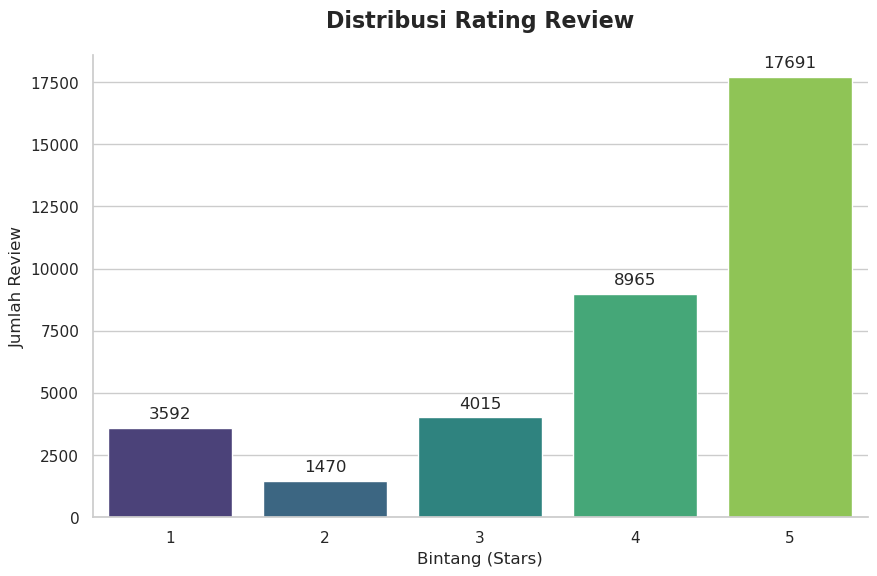

In [87]:
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='stars', data=df, palette='viridis')
plt.title('Distribusi Rating Review', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Bintang (Stars)', fontsize=12)
plt.ylabel('Jumlah Review', fontsize=12)
sns.despine()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10), textcoords='offset points')

plt.show()

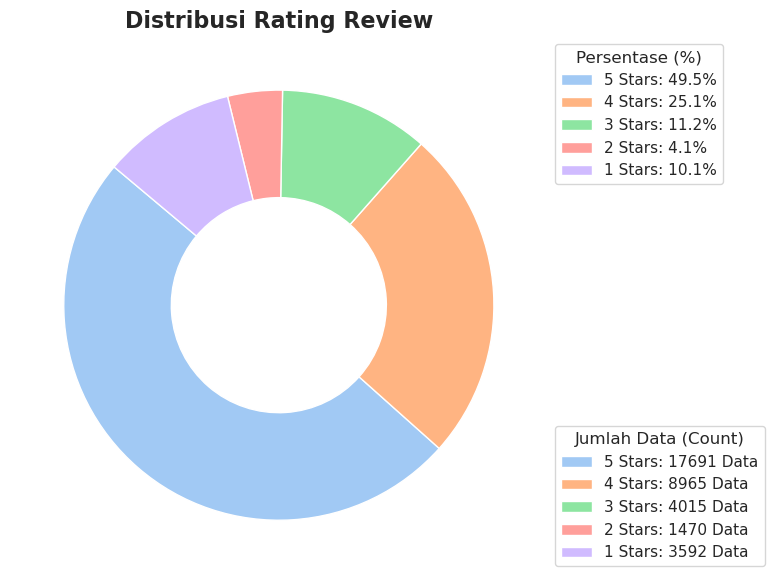

In [88]:
counts = df['stars'].value_counts().sort_index(ascending=False)
sizes = counts.values
labels = counts.index
total = sum(sizes)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('pastel')[0:len(labels)]

wedges, texts = ax.pie(
    sizes,
    colors=colors,
    startangle=140,
    wedgeprops={'width': 0.5}
)
labels_pct = [f'{l} Stars: {(s/total*100):.1f}%' for l, s in zip(labels, sizes)]
labels_count = [f'{l} Stars: {s} Data' for l, s in zip(labels, sizes)]
legend_1 = ax.legend(
    wedges,
    labels_pct,
    title="Persentase (%)",
    loc="upper left",
    bbox_to_anchor=(1, 1)
)
ax.add_artist(legend_1)
legend_2 = ax.legend(
    wedges,
    labels_count,
    title="Jumlah Data (Count)",
    loc="lower left",
    bbox_to_anchor=(1, 0)
)

plt.title('Distribusi Rating Review', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

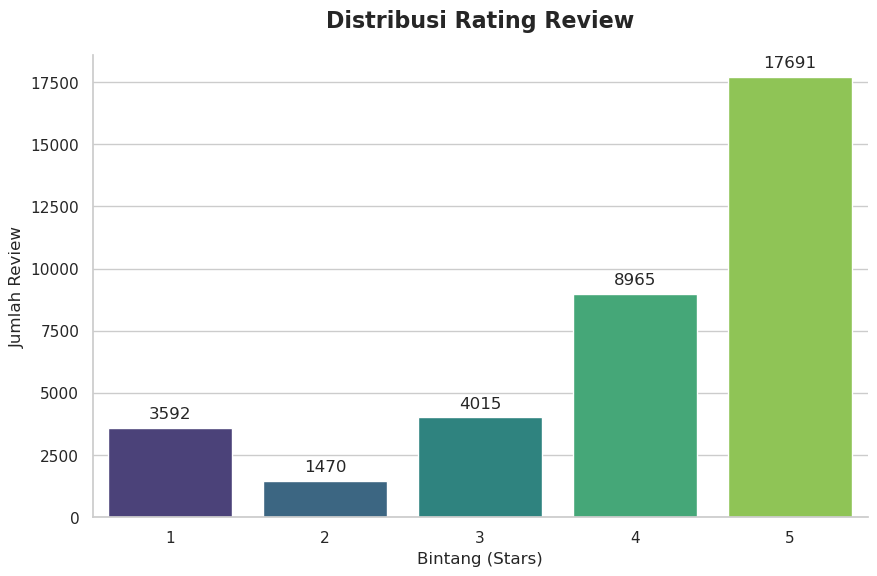

In [89]:
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='stars', data=df, palette='viridis')
plt.title('Distribusi Rating Review', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Bintang (Stars)', fontsize=12)
plt.ylabel('Jumlah Review', fontsize=12)
sns.despine()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10), textcoords='offset points')

plt.show()

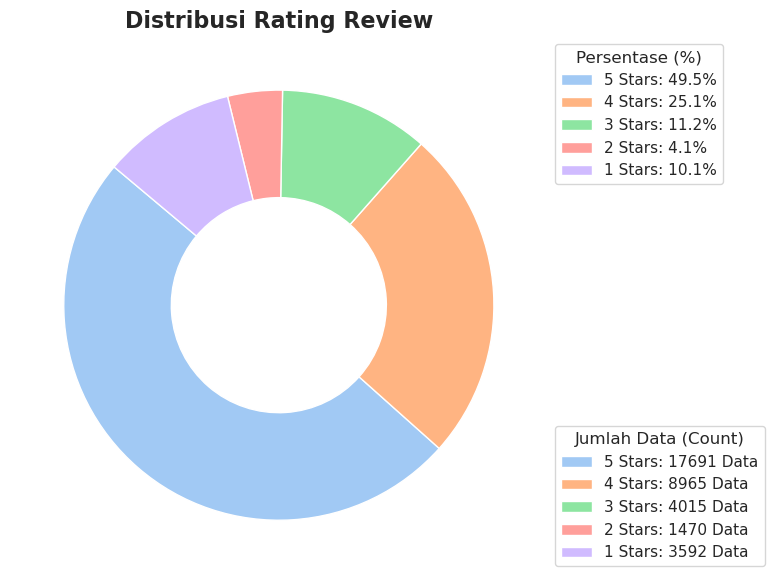

In [90]:
counts = df['stars'].value_counts().sort_index(ascending=False)
sizes = counts.values
labels = counts.index
total = sum(sizes)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('pastel')[0:len(labels)]

wedges, texts = ax.pie(
    sizes,
    colors=colors,
    startangle=140,
    wedgeprops={'width': 0.5}
)
labels_pct = [f'{l} Stars: {(s/total*100):.1f}%' for l, s in zip(labels, sizes)]
labels_count = [f'{l} Stars: {s} Data' for l, s in zip(labels, sizes)]
legend_1 = ax.legend(
    wedges,
    labels_pct,
    title="Persentase (%)",
    loc="upper left",
    bbox_to_anchor=(1, 1)
)
ax.add_artist(legend_1)
legend_2 = ax.legend(
    wedges,
    labels_count,
    title="Jumlah Data (Count)",
    loc="lower left",
    bbox_to_anchor=(1, 0)
)

plt.title('Distribusi Rating Review', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

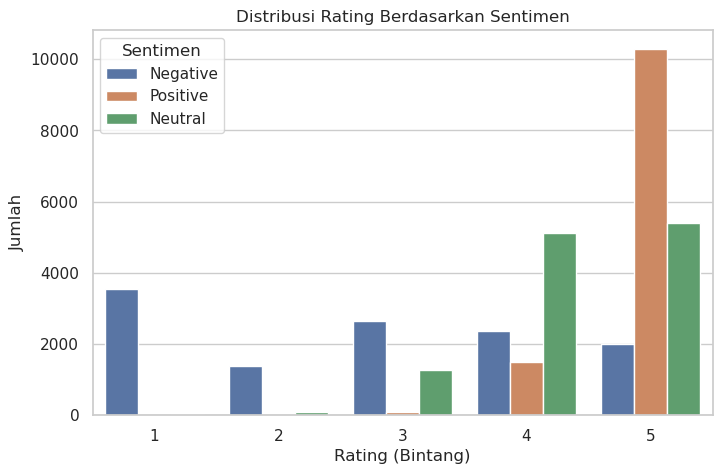

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="stars",
    hue="sentiment_label"
)

plt.title("Distribusi Rating Berdasarkan Sentimen")
plt.xlabel("Rating (Bintang)")
plt.ylabel("Jumlah")
plt.legend(title="Sentimen")
plt.show()


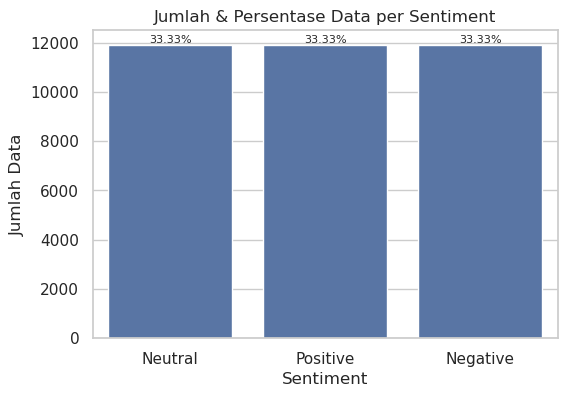

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

# hitung jumlah
sentiment_count = df['sentiment_label'].value_counts().reset_index()
sentiment_count.columns = ['sentiment_label', 'count']

# hitung persentase
sentiment_count['percentage'] = (
    sentiment_count['count'] / sentiment_count['count'].sum() * 100
).round(2)

sns.set(style="whitegrid")

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=sentiment_count,
    x="sentiment_label",
    y="count"
)

# tambahin teks persentase di atas bar
for i, row in sentiment_count.iterrows():
    ax.text(
        i,
        row['count'],
        f"{row['percentage']}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Jumlah & Persentase Data per Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Jumlah Data")
plt.show()
